In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [95]:
data = pd.read_csv("Data Sheet.csv")

In [96]:
data

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,Minor injury,107,11,27,Male,Heavy Vehicle,2,3.484386,Urban,Yes,Rear-end,No,30,Icy
1,Minor injury,27,16,39,Male,Car,2,3.293091,Rural,Yes,Rear-end,Yes,110,Dry
2,Minor injury,87,14,42,Female,Car,3,3.218911,Urban,No,Rear-end,No,59,Dry
3,Minor injury,43,3,60,Female,Heavy Vehicle,2,3.113012,Rural,No,Rear-end,No,73,Wet
4,Minor injury,72,8,70,Male,T.W,3,3.106580,Urban,Yes,Rear-end,Yes,42,Wet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Fatal crash,112,4,30,Male,Car,1,3.248476,Urban,No,Head-on,No,118,Icy
296,Fatal crash,87,21,52,Female,Heavy Vehicle,2,3.037739,Urban,Yes,Rear-end,No,38,Icy
297,Fatal crash,85,20,79,Female,Heavy Vehicle,2,3.350668,Rural,Yes,Rear-end,No,80,Wet
298,Fatal crash,44,5,23,Female,Car,3,3.419304,Urban,Yes,Rear-end,Yes,47,Wet


In [97]:
data.isna()

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,False,False,False,False,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [98]:
data.isna().sum()

Crash_Severity            0
Vehicle_Speed             0
Crash_Time                0
Age                       0
Gender                    0
Vehicle_Type              0
Number_of_Lanes           0
Lane_Width                0
Road_Type                 0
Alcohol_Consumption       0
Crash_Type                0
Seatbelt_Usage            0
Speed_Limit               0
Road_Surface_Condition    0
dtype: int64

In [99]:
data["Vehicle_Type"].value_counts()

Vehicle_Type
Car              107
Heavy Vehicle    105
T.W               88
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

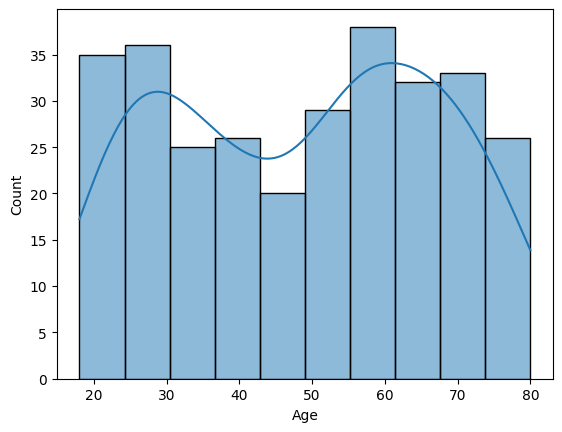

In [100]:
Age = data["Age"]
sns.histplot(data=Age, kde=True)

In [101]:
#Creating a lambda function to create numerical class values
data['Crash_Severity'].value_counts()

Crash_Severity
Minor injury    100
Major injury    100
Fatal crash     100
Name: count, dtype: int64

In [102]:
data['Crash_Severity'].dtype

dtype('O')

In [103]:
data['Crash_Severity'] = data['Crash_Severity'].apply(

    lambda x: 0 if x=="Minor injury" 
              else 1 if x=="Major injury"
              else 2
).astype(int)

In [104]:
data

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,0,107,11,27,Male,Heavy Vehicle,2,3.484386,Urban,Yes,Rear-end,No,30,Icy
1,0,27,16,39,Male,Car,2,3.293091,Rural,Yes,Rear-end,Yes,110,Dry
2,0,87,14,42,Female,Car,3,3.218911,Urban,No,Rear-end,No,59,Dry
3,0,43,3,60,Female,Heavy Vehicle,2,3.113012,Rural,No,Rear-end,No,73,Wet
4,0,72,8,70,Male,T.W,3,3.106580,Urban,Yes,Rear-end,Yes,42,Wet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2,112,4,30,Male,Car,1,3.248476,Urban,No,Head-on,No,118,Icy
296,2,87,21,52,Female,Heavy Vehicle,2,3.037739,Urban,Yes,Rear-end,No,38,Icy
297,2,85,20,79,Female,Heavy Vehicle,2,3.350668,Rural,Yes,Rear-end,No,80,Wet
298,2,44,5,23,Female,Car,3,3.419304,Urban,Yes,Rear-end,Yes,47,Wet


## Dividing the crash time into 4 intervals for better and interpretation

0 -> 0 to 6, ie 1 am to 6 am (Late Night)

1 -> 7 to 11, ie 7 am to 11 pm (Morning)

2 -> 12 to 4, ie 12 pm to 4 pm (Afternoon)

3 -> 5 to 8, ie 5 pm to 8 pm (Evening)

4 ->  9 to 12, ie 9pm to 12pm (Night)

In [105]:

data['Crash_Time'] = data['Crash_Time'].apply(

    lambda x: 0 if (x>=0 and x<=6)
              else 1 if (x>=7 and x<=11)
              else 2 if (x>=12 and x<=16)
              else 3 if (x>=17 and x<=20)
              else 4
)

data['Crash_Time'].value_counts()

Crash_Time
0    88
2    67
1    58
3    55
4    32
Name: count, dtype: int64

## Converting Road conditions into numeric values

0 -> Wet

1 -> Icy

2 -> Dry

In [106]:
data['Road_Surface_Condition'] = data['Road_Surface_Condition'].apply(

    lambda x: 0 if x=='Wet'
              else 1 if x=='Icy'
              else 2
).astype(int)

data['Road_Surface_Condition']

0      1
1      2
2      2
3      0
4      0
      ..
295    1
296    1
297    0
298    0
299    0
Name: Road_Surface_Condition, Length: 300, dtype: int64

In [107]:
data['Crash_Type'] = data['Crash_Type'].apply(

    lambda x: 0 if x=='Rear-end'
              else 1
).astype(int)

data['Crash_Type']

0      0
1      0
2      0
3      0
4      0
      ..
295    1
296    0
297    0
298    0
299    1
Name: Crash_Type, Length: 300, dtype: int64

<Axes: >

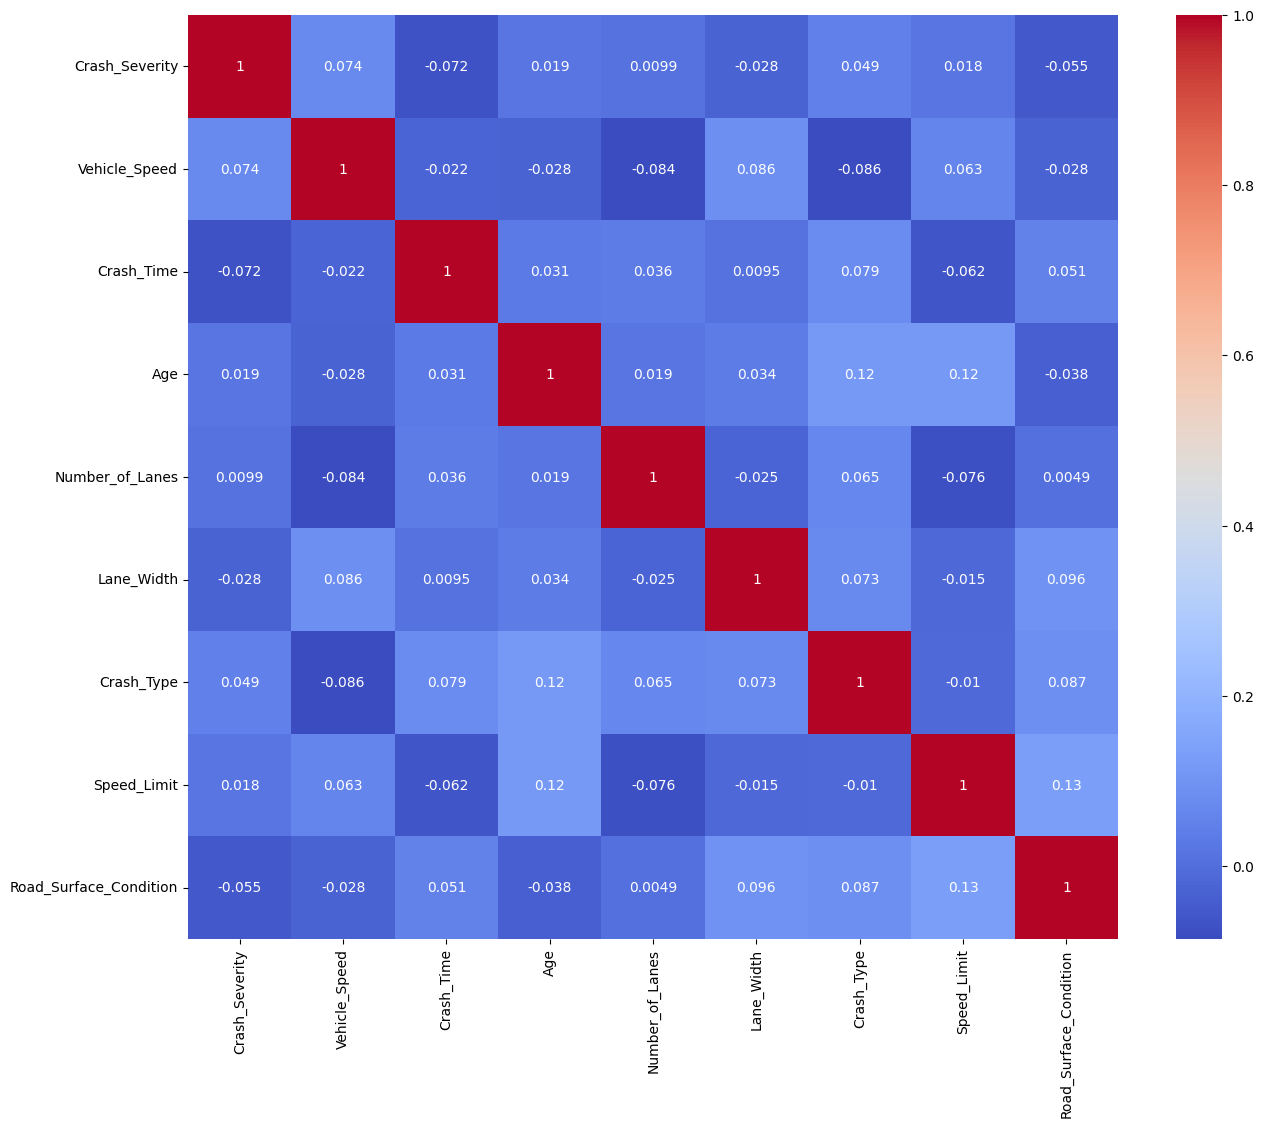

In [108]:
correl = data.corr(numeric_only=True)
pt.figure(figsize=(15, 12))
sns.heatmap(annot=True, data=correl, cmap="coolwarm")

In [109]:
data['Alcohol_Consumption'] = data['Alcohol_Consumption'].apply(


    lambda x: 0 if x=='No'
              else 1

).astype(int)

data['Gender'] = data['Gender'].apply(

    lambda x: 0 if x=='Male'
              else 1


).astype(int)

data['Vehicle_Type'] = data['Vehicle_Type'].apply(

    lambda x: 0 if x=='Car'
              else 1 if x=='Heavy Vehicle'
              else 2

).astype(int)


data['Road_Type'] = data['Road_Type'].apply(

    lambda x: 0 if x=='Rural'
              else 1

).astype(int)

data['Seatbelt_Usage'] = data['Seatbelt_Usage'].apply(

    lambda x: 0 if x=='No'
              else 1

).astype(int)

In [110]:
Prediction = data['Crash_Severity']
Features = data.drop(columns=['Crash_Severity'])

Features

,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,107,1,27,0,1,2,3.484386,1,1,0,0,30,1
1,27,2,39,0,0,2,3.293091,0,1,0,1,110,2
2,87,2,42,1,0,3,3.218911,1,0,0,0,59,2
3,43,0,60,1,1,2,3.113012,0,0,0,0,73,0
4,72,1,70,0,2,3,3.106580,1,1,0,1,42,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,112,0,30,0,0,1,3.248476,1,0,1,0,118,1
296,87,4,52,1,1,2,3.037739,1,1,0,0,38,1
297,85,3,79,1,1,2,3.350668,0,1,0,0,80,0
298,44,0,23,1,0,3,3.419304,1,1,0,1,47,0


## Initial Model using Naive Bayes Classifier

In [111]:
trained_features, tested_features, trained_predictions, tested_predictions = train_test_split(Features, Prediction, test_size=0.3, random_state=40)

NaiveBayes = GaussianNB()
NaiveBayes.fit(trained_features, trained_predictions)

AccPredicted = NaiveBayes.predict(tested_features)

acc_score = accuracy_score(tested_predictions, AccPredicted)

print(acc_score*100)

32.22222222222222


## Now using Decision Tree Classifier

In [112]:
trained_features, tested_features, trained_predictions, tested_predictions = train_test_split(Features, Prediction, test_size=0.3, random_state=40)

Dtree = DecisionTreeClassifier()
Dtree.fit(trained_features, trained_predictions)

AccPredicted = Dtree.predict(tested_features)
acc_score = accuracy_score(tested_predictions, AccPredicted)

print(acc_score*100)

30.0


## 

<Axes: >

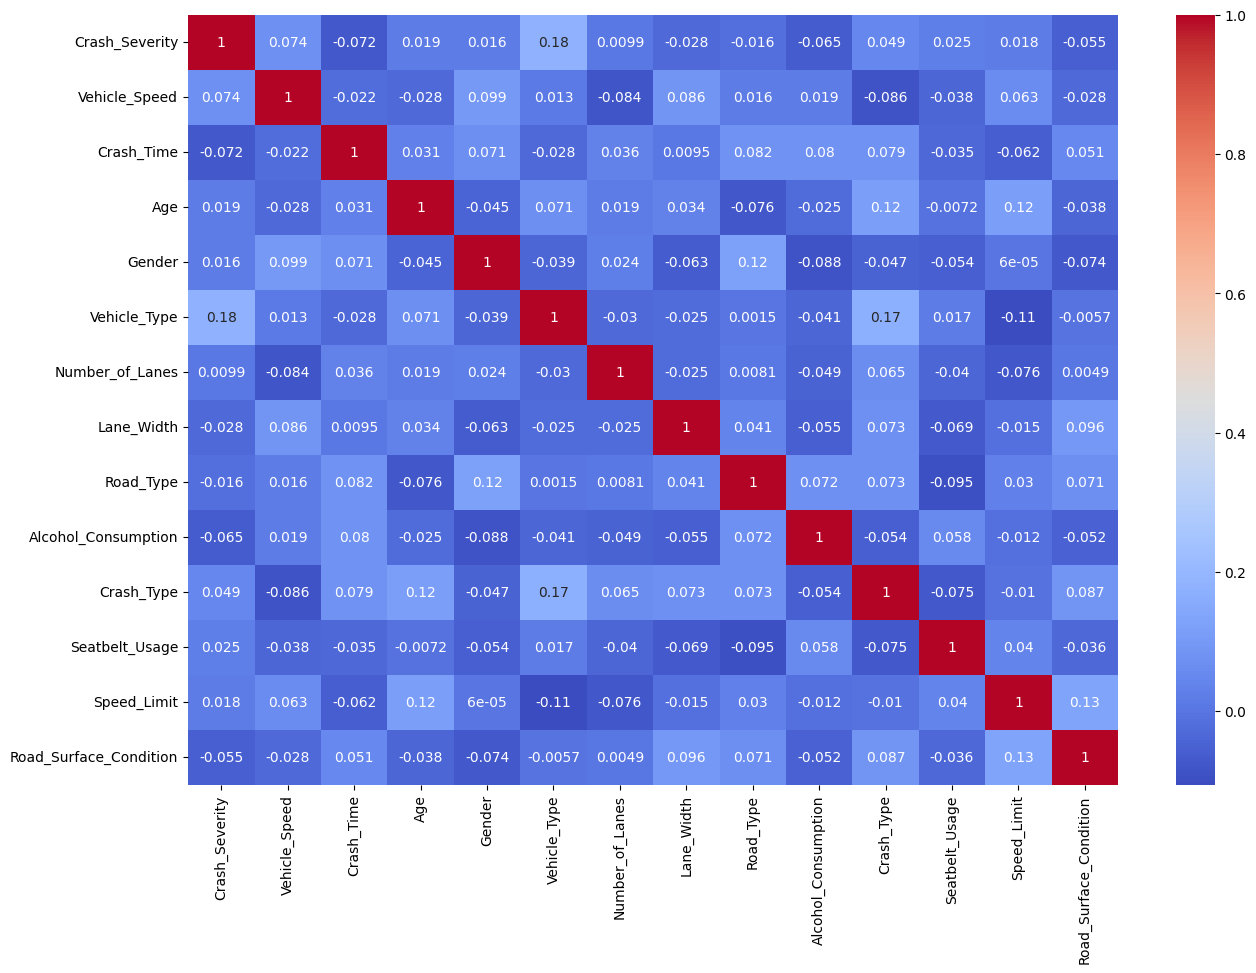

In [113]:
correl = data.corr(numeric_only=True)
pt.figure(figsize=(15, 10))
sns.heatmap(correl, cmap='coolwarm', annot=True)

In [114]:
data['Crash_Severity'].corr(data['Road_Surface_Condition'])

np.float64(-0.05460284360963457)

In [115]:
Prediction1 = data['Crash_Severity']
Features1 = data[['Vehicle_Type', 'Vehicle_Speed', 'Crash_Time', 'Age', 'Crash_Type', 'Seatbelt_Usage']]


trained_features, tested_features, trained_predictions, tested_predictions = train_test_split(Features1, Prediction1, test_size=0.4, random_state=50)

NaiveBayes = GaussianNB()
NaiveBayes.fit(trained_features, trained_predictions)

AccPredicted = NaiveBayes.predict(tested_features)

acc_score = accuracy_score(tested_predictions, AccPredicted)

print(acc_score*100)

33.33333333333333


In [116]:
data['Lane_Width'] = data['Lane_Width'].round(decimals=1)
data['Lane_Width'].value_counts()

Lane_Width
3.4    74
3.3    59
3.2    56
3.1    47
3.5    37
3.0    27
Name: count, dtype: int64

In [117]:
Prediction = data['Crash_Severity']
Features = data.drop(columns=['Crash_Severity'])

trained_features, tested_features, trained_predictions, tested_predictions = train_test_split(Features, Prediction, test_size=0.3, random_state=40)

NaiveBayes = GaussianNB()
NaiveBayes.fit(trained_features, trained_predictions)

AccPredicted = NaiveBayes.predict(tested_features)

acc_score = accuracy_score(tested_predictions, AccPredicted)

print(acc_score*100)

32.22222222222222


<Axes: >

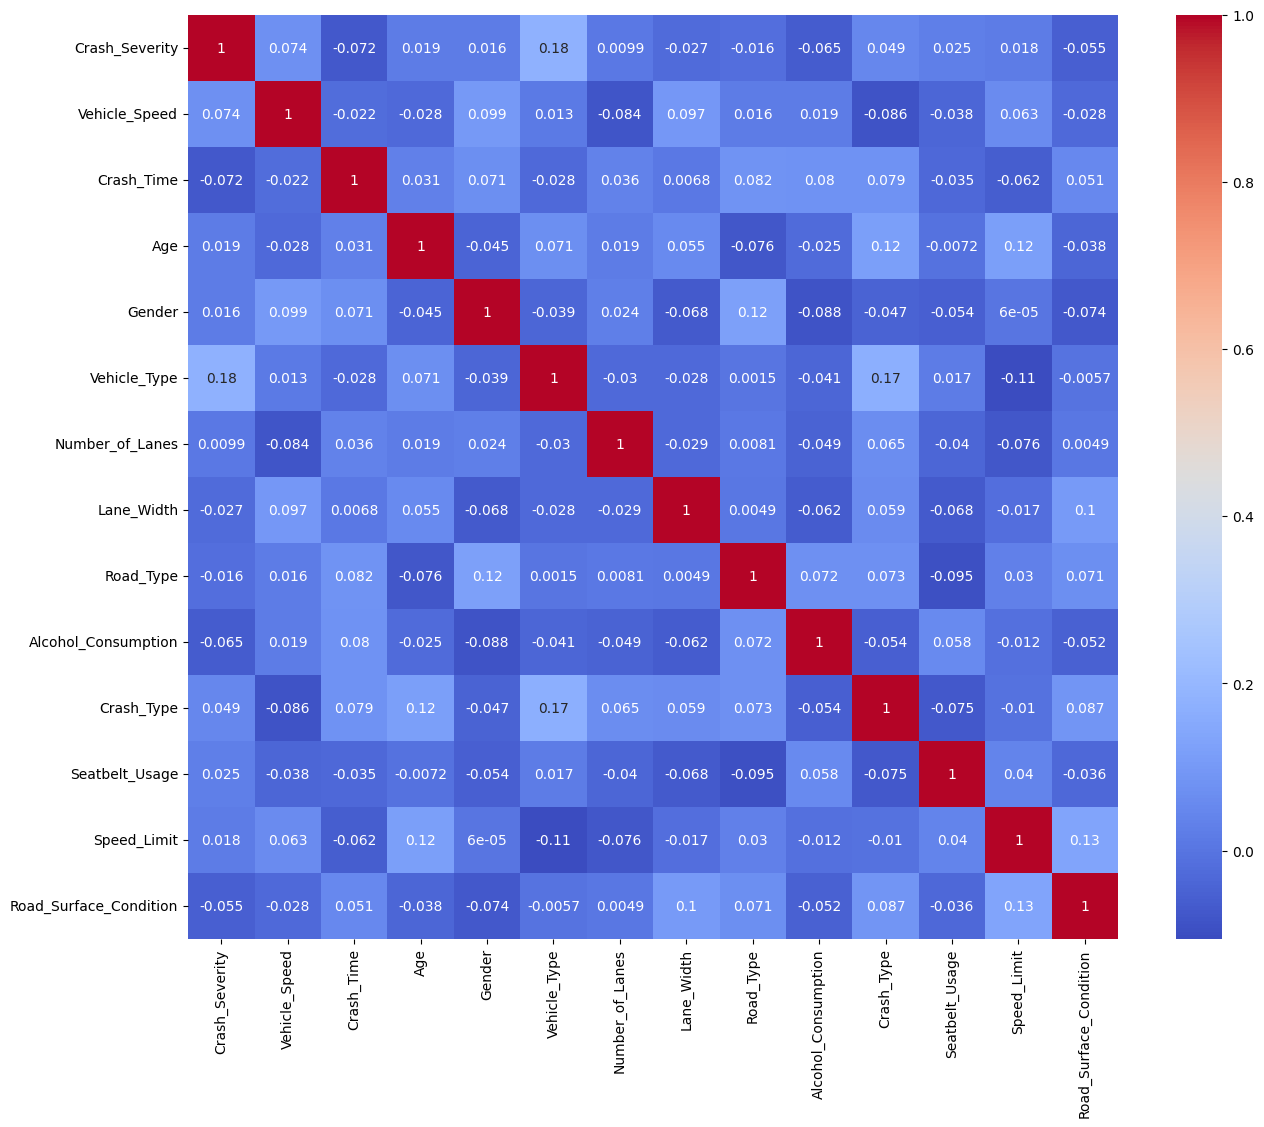

In [118]:
correl = data.corr()
pt.figure(figsize=(15, 12))
sns.heatmap(correl, cmap="coolwarm", annot=True)

In [119]:
data['Vehicle_Speed'].value_counts()

Vehicle_Speed
27     7
43     7
72     6
109    6
30     6
      ..
77     1
51     1
91     1
29     1
66     1
Name: count, Length: 105, dtype: int64

In [120]:
data['Vehicle_Speed'] = data['Vehicle_Speed'].apply(

    lambda x: 0 if (x>=0 and x<=20)
              else 1 if (x>=21 and x<=40)
              else 2 if (x>=41 and x<=60)
              else 3 if (x>=61 and x<=80)
              else 4
)

data['Vehicle_Speed'].value_counts()

Vehicle_Speed
4    106
2     64
1     60
3     44
0     26
Name: count, dtype: int64

<Axes: >

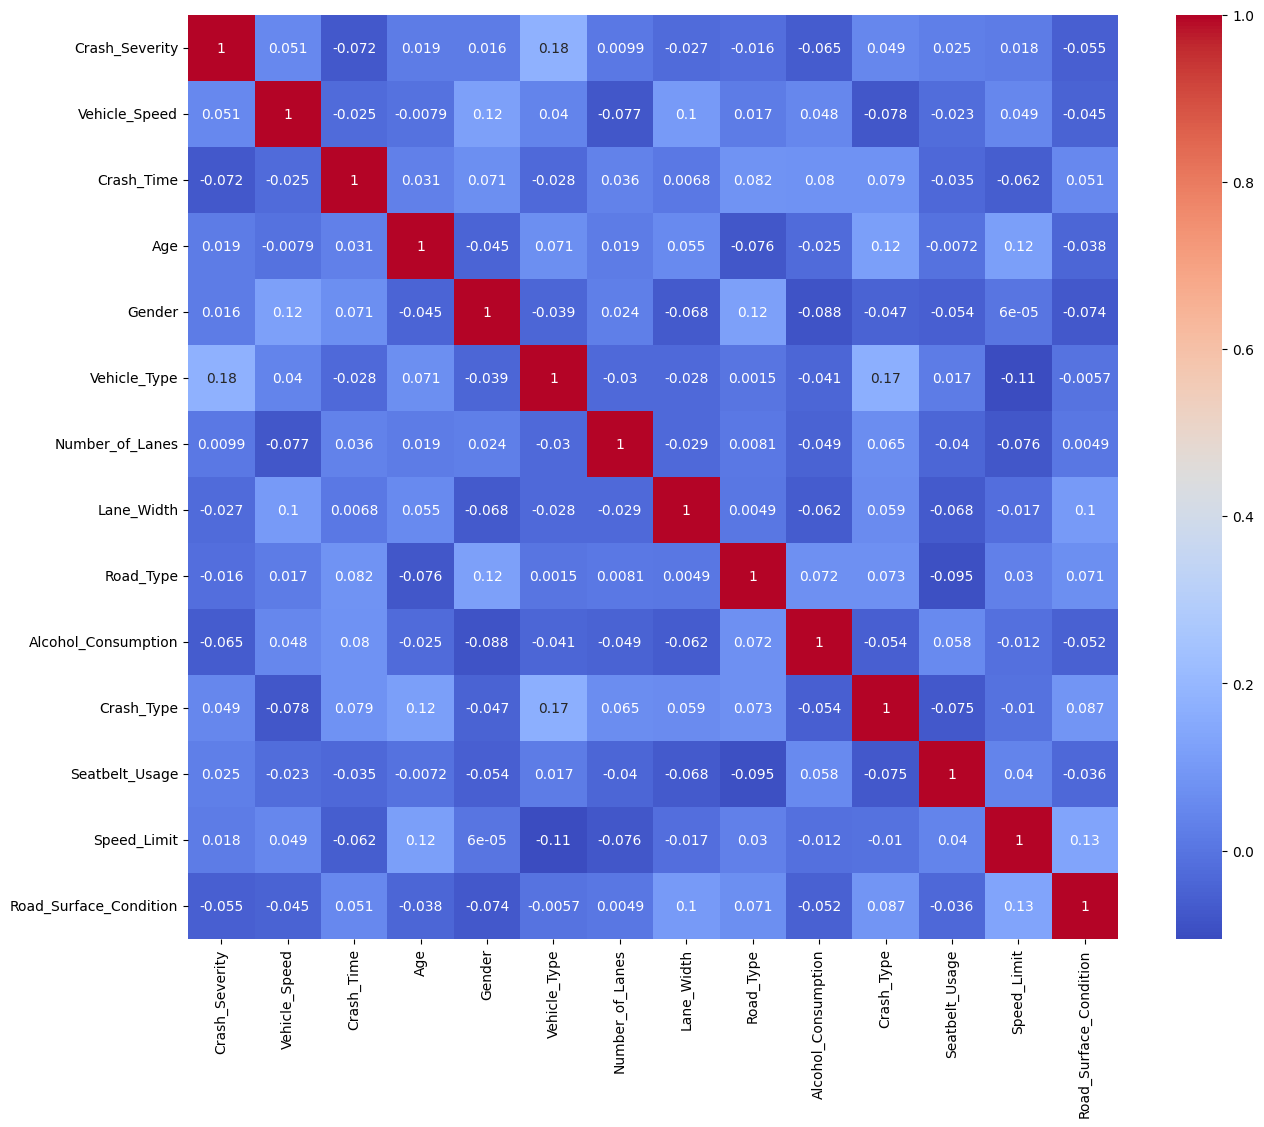

In [121]:
correl = data.corr()
pt.figure(figsize=(15, 12))
sns.heatmap(correl, cmap="coolwarm", annot=True)

Tuned Random Forest Accuracy: 30.00%
Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.30      0.31        30
           1       0.27      0.22      0.24        32
           2       0.31      0.39      0.35        28

    accuracy                           0.30        90
   macro avg       0.30      0.30      0.30        90
weighted avg       0.30      0.30      0.30        90



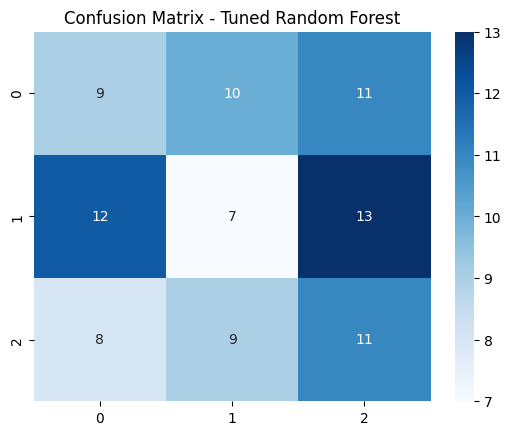

In [122]:
Prediction1 = data['Crash_Severity']
Features1 = data[['Vehicle_Type', 'Vehicle_Speed', 'Crash_Time', 'Age', 'Crash_Type', 'Seatbelt_Usage']]

trained_features, tested_features, trained_predictions, tested_predictions = train_test_split(Features1, Prediction1, test_size=0.3, random_state=40)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# Define Parameter Grid
param_grid = {
'n_estimators': [50, 100, 200],
'max_depth': [5, 10, 20],
'min_samples_split': [2, 5, 10]
}
# Grid Search
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
param_grid, cv=5, scoring='accuracy')
grid_search.fit(trained_features, trained_predictions)
# Best Model
best_rf = grid_search.best_estimator_
rf_predictions = best_rf.predict(tested_features)
# Evaluation
tuned_rf_accuracy = accuracy_score(tested_predictions, rf_predictions)
print(f"Tuned Random Forest Accuracy: {tuned_rf_accuracy*100:.2f}%")
print("Classification Report:")
print(classification_report(tested_predictions, rf_predictions))
# Confusion Matrix
cm = confusion_matrix(tested_predictions, rf_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
pt.title("Confusion Matrix - Tuned Random Forest")
pt.show()

In [123]:
data

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,0,4,1,27,0,1,2,3.5,1,1,0,0,30,1
1,0,1,2,39,0,0,2,3.3,0,1,0,1,110,2
2,0,4,2,42,1,0,3,3.2,1,0,0,0,59,2
3,0,2,0,60,1,1,2,3.1,0,0,0,0,73,0
4,0,3,1,70,0,2,3,3.1,1,1,0,1,42,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2,4,0,30,0,0,1,3.2,1,0,1,0,118,1
296,2,4,4,52,1,1,2,3.0,1,1,0,0,38,1
297,2,4,3,79,1,1,2,3.4,0,1,0,0,80,0
298,2,2,0,23,1,0,3,3.4,1,1,0,1,47,0


In [124]:
alcohol_data = data[data['Crash_Severity']  == 2]

In [125]:
alcohol_data

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
200,2,4,2,43,0,1,3,3.2,0,1,1,0,75,2
201,2,1,0,20,1,2,3,3.3,1,1,1,0,34,2
202,2,2,0,60,1,1,1,3.0,0,1,0,0,64,0
203,2,0,2,57,1,0,1,3.3,0,0,0,1,82,0
204,2,1,0,57,0,0,1,3.4,1,1,0,1,106,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2,4,0,30,0,0,1,3.2,1,0,1,0,118,1
296,2,4,4,52,1,1,2,3.0,1,1,0,0,38,1
297,2,4,3,79,1,1,2,3.4,0,1,0,0,80,0
298,2,2,0,23,1,0,3,3.4,1,1,0,1,47,0


In [126]:
alcohol_data = alcohol_data[['Crash_Severity', 'Alcohol_Consumption']]

In [127]:
sample_alcohol_data = alcohol_data

label = [0, 1]

sum0 = 0
sum1 = 0

for entry in sample_alcohol_data['Alcohol_Consumption']:

    # print(entry)
    if entry == 0:
        sum0 = sum0 + 1
    else:
        sum1 = sum1 + 1

list0 = []
list1 = [] 
list0.append(sum0)
list1.append(sum1)

list0

[58]

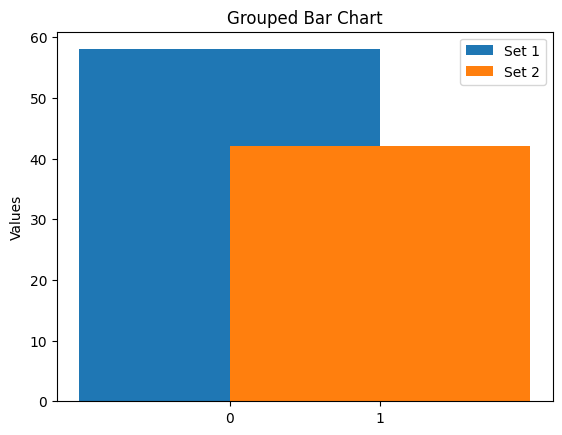

In [128]:
w, x = 1, np.arange(len(label))

fig, ax = pt.subplots()
ax.bar(x - w/2, list0, width=w, label='Set 1')
ax.bar(x + w/2, list1, width=w, label='Set 2')

ax.set_xticks(x)
ax.set_xticklabels(label)
ax.set_ylabel('Values')
ax.set_title('Grouped Bar Chart')
ax.legend()

pt.show()

In [129]:
data_snapshot = pd.read_csv('Data Sheet.csv')
data_snapshot

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Gender,Vehicle_Type,Number_of_Lanes,Lane_Width,Road_Type,Alcohol_Consumption,Crash_Type,Seatbelt_Usage,Speed_Limit,Road_Surface_Condition
0,Minor injury,107,11,27,Male,Heavy Vehicle,2,3.484386,Urban,Yes,Rear-end,No,30,Icy
1,Minor injury,27,16,39,Male,Car,2,3.293091,Rural,Yes,Rear-end,Yes,110,Dry
2,Minor injury,87,14,42,Female,Car,3,3.218911,Urban,No,Rear-end,No,59,Dry
3,Minor injury,43,3,60,Female,Heavy Vehicle,2,3.113012,Rural,No,Rear-end,No,73,Wet
4,Minor injury,72,8,70,Male,T.W,3,3.106580,Urban,Yes,Rear-end,Yes,42,Wet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Fatal crash,112,4,30,Male,Car,1,3.248476,Urban,No,Head-on,No,118,Icy
296,Fatal crash,87,21,52,Female,Heavy Vehicle,2,3.037739,Urban,Yes,Rear-end,No,38,Icy
297,Fatal crash,85,20,79,Female,Heavy Vehicle,2,3.350668,Rural,Yes,Rear-end,No,80,Wet
298,Fatal crash,44,5,23,Female,Car,3,3.419304,Urban,Yes,Rear-end,Yes,47,Wet


In [130]:
data_snapshot['Lane_Width'] = data_snapshot['Lane_Width'].apply(

    lambda x: round(x, 3)
)

bins = [-1, 6, 12, 16, 20, 23]
labels = ['Late Night', 'Morning', 'Afternoon', 'Evening', 'Night']
data_snapshot['Crash_Time_Category'] = pd.cut(data_snapshot['Crash_Time'],labels=labels, bins=bins)

## APPLYING ONE HOT ENCODING TO NOMINAL DATA ATTRIBUTES

In [131]:
refined_data = pd.get_dummies(data_snapshot, columns=['Gender', 'Vehicle_Type', 'Road_Type', 'Alcohol_Consumption', 'Crash_Type', 'Seatbelt_Usage', 'Crash_Time_Category'])
refined_data


,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Number_of_Lanes,Lane_Width,Speed_Limit,Road_Surface_Condition,Gender_Female,Gender_Male,...,Alcohol_Consumption_Yes,Crash_Type_Head-on,Crash_Type_Rear-end,Seatbelt_Usage_No,Seatbelt_Usage_Yes,Crash_Time_Category_Late Night,Crash_Time_Category_Morning,Crash_Time_Category_Afternoon,Crash_Time_Category_Evening,Crash_Time_Category_Night
0,Minor injury,107,11,27,2,3.484,30,Icy,False,True,...,True,False,True,True,False,False,True,False,False,False
1,Minor injury,27,16,39,2,3.293,110,Dry,False,True,...,True,False,True,False,True,False,False,True,False,False
2,Minor injury,87,14,42,3,3.219,59,Dry,True,False,...,False,False,True,True,False,False,False,True,False,False
3,Minor injury,43,3,60,2,3.113,73,Wet,True,False,...,False,False,True,True,False,True,False,False,False,False
4,Minor injury,72,8,70,3,3.107,42,Wet,False,True,...,True,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Fatal crash,112,4,30,1,3.248,118,Icy,False,True,...,False,True,False,True,False,True,False,False,False,False
296,Fatal crash,87,21,52,2,3.038,38,Icy,True,False,...,True,False,True,True,False,False,False,False,False,True
297,Fatal crash,85,20,79,2,3.351,80,Wet,True,False,...,True,False,True,True,False,False,False,False,True,False
298,Fatal crash,44,5,23,3,3.419,47,Wet,True,False,...,True,False,True,False,True,True,False,False,False,False


In [132]:
road_condition_map = {

    'Dry': 0,
    'Wet': 1,
    'Icy': 2
}

refined_data['Road_Surface_Condition'] = refined_data['Road_Surface_Condition'].map(road_condition_map)

refined_data

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Number_of_Lanes,Lane_Width,Speed_Limit,Road_Surface_Condition,Gender_Female,Gender_Male,...,Alcohol_Consumption_Yes,Crash_Type_Head-on,Crash_Type_Rear-end,Seatbelt_Usage_No,Seatbelt_Usage_Yes,Crash_Time_Category_Late Night,Crash_Time_Category_Morning,Crash_Time_Category_Afternoon,Crash_Time_Category_Evening,Crash_Time_Category_Night
0,Minor injury,107,11,27,2,3.484,30,2,False,True,...,True,False,True,True,False,False,True,False,False,False
1,Minor injury,27,16,39,2,3.293,110,0,False,True,...,True,False,True,False,True,False,False,True,False,False
2,Minor injury,87,14,42,3,3.219,59,0,True,False,...,False,False,True,True,False,False,False,True,False,False
3,Minor injury,43,3,60,2,3.113,73,1,True,False,...,False,False,True,True,False,True,False,False,False,False
4,Minor injury,72,8,70,3,3.107,42,1,False,True,...,True,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,Fatal crash,112,4,30,1,3.248,118,2,False,True,...,False,True,False,True,False,True,False,False,False,False
296,Fatal crash,87,21,52,2,3.038,38,2,True,False,...,True,False,True,True,False,False,False,False,False,True
297,Fatal crash,85,20,79,2,3.351,80,1,True,False,...,True,False,True,True,False,False,False,False,True,False
298,Fatal crash,44,5,23,3,3.419,47,1,True,False,...,True,False,True,False,True,True,False,False,False,False


In [133]:
severity_map = {

    'Minor injury': 0,
    'Major injury': 1,
    'Fatal crash': 1
}

refined_data['Crash_Severity'] = refined_data['Crash_Severity'].map(severity_map)

refined_data

,Crash_Severity,Vehicle_Speed,Crash_Time,Age,Number_of_Lanes,Lane_Width,Speed_Limit,Road_Surface_Condition,Gender_Female,Gender_Male,...,Alcohol_Consumption_Yes,Crash_Type_Head-on,Crash_Type_Rear-end,Seatbelt_Usage_No,Seatbelt_Usage_Yes,Crash_Time_Category_Late Night,Crash_Time_Category_Morning,Crash_Time_Category_Afternoon,Crash_Time_Category_Evening,Crash_Time_Category_Night
0,0,107,11,27,2,3.484,30,2,False,True,...,True,False,True,True,False,False,True,False,False,False
1,0,27,16,39,2,3.293,110,0,False,True,...,True,False,True,False,True,False,False,True,False,False
2,0,87,14,42,3,3.219,59,0,True,False,...,False,False,True,True,False,False,False,True,False,False
3,0,43,3,60,2,3.113,73,1,True,False,...,False,False,True,True,False,True,False,False,False,False
4,0,72,8,70,3,3.107,42,1,False,True,...,True,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,112,4,30,1,3.248,118,2,False,True,...,False,True,False,True,False,True,False,False,False,False
296,1,87,21,52,2,3.038,38,2,True,False,...,True,False,True,True,False,False,False,False,False,True
297,1,85,20,79,2,3.351,80,1,True,False,...,True,False,True,True,False,False,False,False,True,False
298,1,44,5,23,3,3.419,47,1,True,False,...,True,False,True,False,True,True,False,False,False,False


In [136]:
#Splitting into class and features
refined_data = refined_data.drop(columns=['Gender', 'Vehicle_Type', 'Road_Type', 'Alcohol_Consumption', 'Crash_Type', 'Seatbelt_Usage', 'Crash_Time_Category', 'Crash_Time'], axis=1, errors='ignore')
Features = refined_data.drop(columns=['Crash_Severity'], axis=1, errors='ignore') #X
Class = refined_data['Crash_Severity'] #Y

X_train, X_test, Y_train, Y_test = train_test_split(Features, Class, test_size=0.1, stratify=Class, shuffle=True)

count_minor_injury = np.sum(Y_train == 0)
count_major_fatal = np.sum(Y_train == 1)

scale_pos_weight_value = count_minor_injury / count_major_fatal

smote = SMOTE(random_state=42)
X_train, Y_train = smote.fit_resample(X_train, Y_train)

Starting GridSearchCV for XGBoost. This may take some time...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best XGBoost parameters found: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}

Tuned XGBoost Accuracy on Test Set: 73.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.83      0.75      0.79        20

    accuracy                           0.73        30
   macro avg       0.71      0.72      0.71        30
weighted avg       0.75      0.73      0.74        30



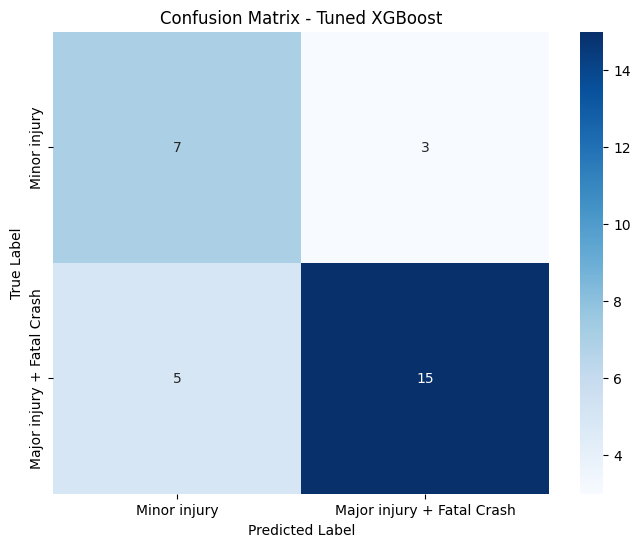

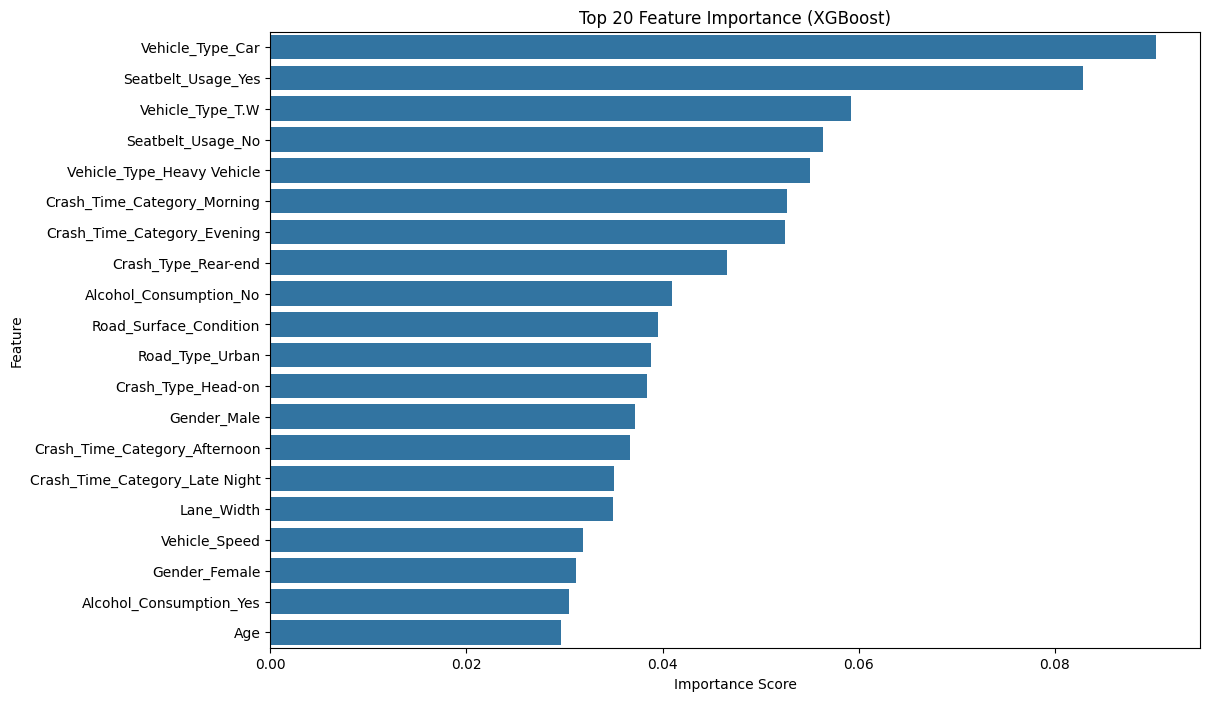

In [137]:
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, scale_pos_weight=scale_pos_weight_value)

# --- Step 2: Define the Hyperparameter Grid for GridSearchCV ---
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
}


# --- Step 3: Set up and Run GridSearchCV ---
print("Starting GridSearchCV for XGBoost. This may take some time...")
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=1)
grid_search_xgb.fit(X_train, Y_train)

# Get the best model after tuning
best_xgb = grid_search_xgb.best_estimator_
print(f"\nBest XGBoost parameters found: {grid_search_xgb.best_params_}")

# --- Step 4: Make Predictions and Evaluate the Best Model ---
xgb_predictions = best_xgb.predict(X_test)

tuned_xgb_accuracy = accuracy_score(Y_test, xgb_predictions)
print(f"\nTuned XGBoost Accuracy on Test Set: {tuned_xgb_accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(Y_test, xgb_predictions))

# Confusion Matrix Visualization
cm_xgb = confusion_matrix(Y_test, xgb_predictions)
pt.figure(figsize=(8, 6))
# Define your class labels based on your Crash_Severity mapping (e.g., 0:Minor, 1:Major, 2:Fatal)
class_labels = ['Minor injury', 'Major injury + Fatal Crash'] # <--- ADJUST THIS LIST TO YOUR ACTUAL LABELS AND THEIR MAPPED ORDER
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
pt.title("Confusion Matrix - Tuned XGBoost")
pt.xlabel("Predicted Label")
pt.ylabel("True Label")
pt.show()

# --- Step 5: Extract and Visualize Feature Importance ---
if hasattr(best_xgb, 'feature_importances_'):
    importance = best_xgb.feature_importances_
    features = X_train.columns
    feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    pt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
    pt.title('Top 20 Feature Importance (XGBoost)')
    pt.xlabel('Importance Score')
    pt.ylabel('Feature')
    pt.show()

## Using Stratified K-Fold + XGBOOST

In [160]:
#Some new interaction terms

refined_data['Alcohol_At_Night'] = refined_data['Alcohol_Consumption_Yes'] * refined_data['Crash_Time_Category_Night'] 
refined_data['Alcohol_Without_Seatbelt'] = refined_data['Alcohol_Consumption_Yes'] * refined_data['Seatbelt_Usage_No']
refined_data['Speeding_With_Alcohol'] = refined_data['Alcohol_Consumption_Yes'] * refined_data['Vehicle_Speed'] * refined_data['Road_Surface_Condition']
refined_data['Speeding_Without_Alcohol'] = refined_data['Alcohol_Consumption_No'] * refined_data['Vehicle_Speed'] * refined_data['Road_Surface_Condition']

refined_data['Speeding_Car_Without_Seatbelt'] = refined_data['Seatbelt_Usage_No'] * refined_data['Vehicle_Speed'] * refined_data['Road_Surface_Condition'] * refined_data['Vehicle_Type_Car']
refined_data['Speeding_with_TW_WO_Seatbelt'] = refined_data['Vehicle_Speed'] * refined_data['Vehicle_Type_T.W'] * refined_data['Seatbelt_Usage_No']
refined_data['Speeding_On_Icy_Road'] = refined_data['Vehicle_Speed'] * (refined_data['Road_Surface_Condition'] == 2).astype(int)

refined_data['Male_With_Alcohol'] = refined_data['Gender_Male'] * refined_data['Alcohol_Consumption_Yes']
refined_data['Speeding_Car_With_Drunk_Driver'] = refined_data['Vehicle_Type_Car'] * refined_data['Alcohol_Consumption_Yes'] * refined_data['Vehicle_Speed']

In [161]:
refined_data.columns

Index(['Crash_Severity', 'Vehicle_Speed', 'Age', 'Number_of_Lanes',
       'Lane_Width', 'Speed_Limit', 'Road_Surface_Condition', 'Gender_Female',
       'Gender_Male', 'Vehicle_Type_Car', 'Vehicle_Type_Heavy Vehicle',
       'Vehicle_Type_T.W', 'Road_Type_Rural', 'Road_Type_Urban',
       'Alcohol_Consumption_No', 'Alcohol_Consumption_Yes',
       'Crash_Type_Head-on', 'Crash_Type_Rear-end', 'Seatbelt_Usage_No',
       'Seatbelt_Usage_Yes', 'Crash_Time_Category_Late Night',
       'Crash_Time_Category_Morning', 'Crash_Time_Category_Afternoon',
       'Crash_Time_Category_Evening', 'Crash_Time_Category_Night',
       'Alcohol_At_Night', 'Speeding_With_Alcohol',
       'Speeding_with_TW_WO_Seatbelt', 'Alcohol_Without_Seatbelt',
       'Speeding_Without_Alcohol', 'Speeding_Car_Without_Seatbelt',
       'Speeding_On_Icy_Road', 'Male_With_Alcohol',
       'Speeding_Car_With_Drunk_Driver'],
      dtype='object')

In [162]:
refined_data1 = refined_data[['Crash_Severity','Vehicle_Type_Car', 'Alcohol_At_Night', 'Speeding_With_Alcohol',
       'Speeding_with_TW_WO_Seatbelt', 'Speeding_Car_Without_Seatbelt', 'Alcohol_Without_Seatbelt', 'Speeding_Car_With_Drunk_Driver']]

In [163]:
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

Features = refined_data1.drop(columns=['Crash_Severity'], axis=1, errors='ignore') #X
Class = refined_data1['Crash_Severity']

xgb_estimator = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    colsample_bytree=1.0,
    learning_rate=0.2,
    max_depth=15,
    n_estimators=1000,
    subsample=0.7
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline including SMOTE and the Classifier
model_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb_estimator)
])

# Lists to store metrics from each fold
accuracies = []
balanced_accuracies = []
classification_reports = []

print("Starting Cross-Validation for Accuracy Evaluation...")
for fold, (train_idx, test_idx) in enumerate(cv_strategy.split(Features, Class)):
    X_train, X_test = Features.iloc[train_idx], Features.iloc[test_idx]
    y_train, y_test = Class.iloc[train_idx], Class.iloc[test_idx]

    # Fit the pipeline (SMOTE will be applied to X_train, y_train within the pipeline)
    model_pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = model_pipeline.predict(X_test)

    # Calculate metrics
    fold_accuracy = accuracy_score(y_test, y_pred)
    fold_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    fold_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    accuracies.append(fold_accuracy)
    balanced_accuracies.append(fold_balanced_accuracy)
    classification_reports.append(fold_report)

    print(f"\n--- Fold {fold+1} Results ---")
    print(f"Accuracy: {fold_accuracy:.4f}")
    print(f"Balanced Accuracy: {fold_balanced_accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

# Aggregate and print overall results
print("\n--- Overall Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(accuracies):.4f} (+/- {np.std(accuracies):.4f})")
print(f"Average Balanced Accuracy: {np.mean(balanced_accuracies):.4f} (+/- {np.std(balanced_accuracies):.4f})")

# Example of how to get average F1-score for class 1 (Major/Fatal)
avg_f1_class_1 = np.mean([report['1']['f1-score'] for report in classification_reports])
print(f"Average F1-score for Major/Fatal Crashes (Class 1): {avg_f1_class_1:.4f}")

Starting Cross-Validation for Accuracy Evaluation...

--- Fold 1 Results ---
Accuracy: 0.6000
Balanced Accuracy: 0.5625
Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.45      0.43        20
           1       0.71      0.68      0.69        40

    accuracy                           0.60        60
   macro avg       0.56      0.56      0.56        60
weighted avg       0.61      0.60      0.60        60


--- Fold 2 Results ---
Accuracy: 0.6000
Balanced Accuracy: 0.5125
Classification Report:
              precision    recall  f1-score   support

           0       0.36      0.25      0.29        20
           1       0.67      0.78      0.72        40

    accuracy                           0.60        60
   macro avg       0.52      0.51      0.51        60
weighted avg       0.57      0.60      0.58        60


--- Fold 3 Results ---
Accuracy: 0.5667
Balanced Accuracy: 0.4875
Classification Report:
              precision